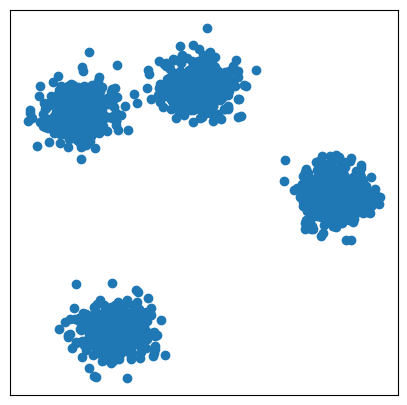

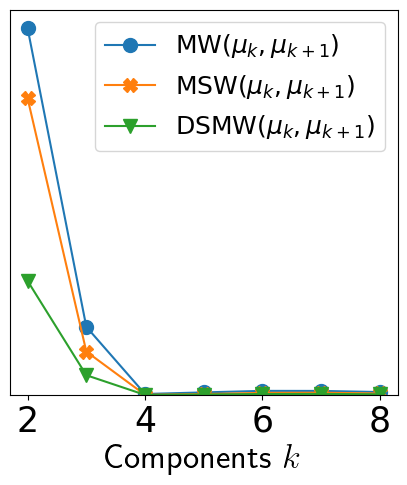

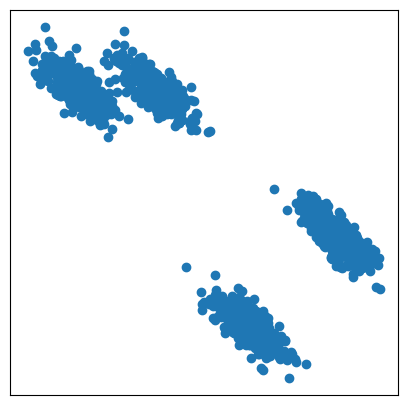

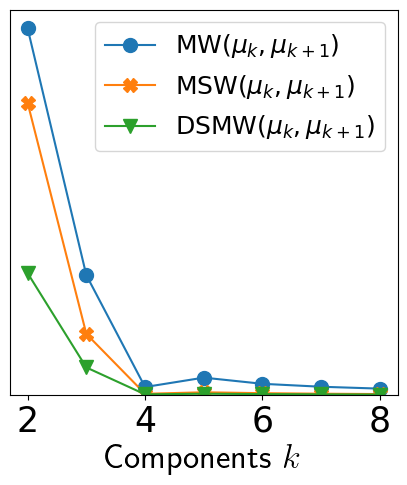

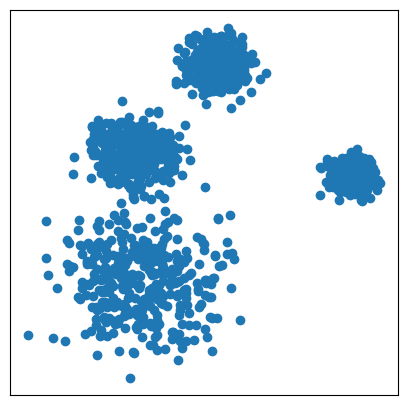

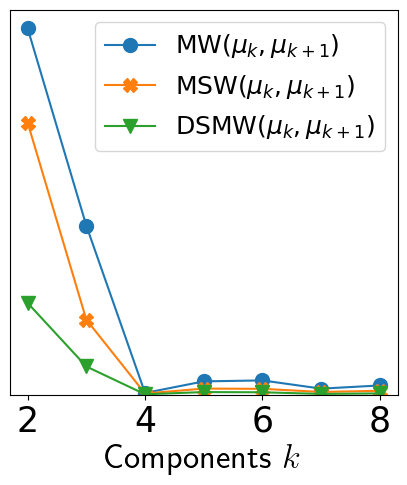

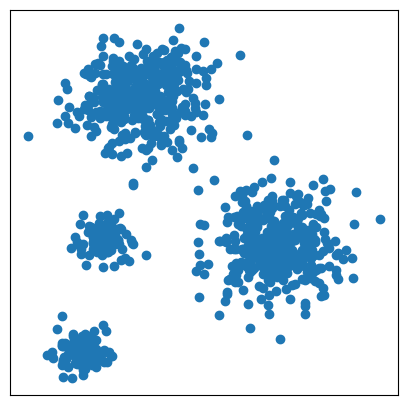

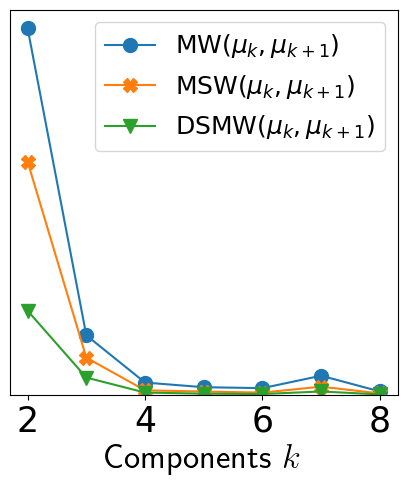

In [2]:
import numpy as np
from sklearn.datasets import make_blobs
import torch
import os
import numpy as np
import GMM_utils as GMM
import sliced_mw as SMW
import matplotlib.pyplot as plt
from tqdm import tqdm
import sklearn
import numpy as np
import ot
import scipy.stats as sps
import scipy.linalg as spl
from scipy.optimize import linprog
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 25})

def GaussianW2(m0,m1,Sigma0,Sigma1):
    # Wasserstein between Gaussians
    # source: https://github.com/judelo
    Sigma00  = spl.sqrtm(Sigma0)
    Sigma010 = spl.sqrtm(Sigma00@Sigma1@Sigma00)
    d = np.linalg.norm(m0-m1)**2
    d =+np.trace(Sigma0+Sigma1-2*Sigma010)
    return d

def MW2(pi_0,pi_1,mu_0,mu_1,Sigma0_arr,Sigma1_arr):
    # Return the MW2 distance between two GMMs
    # source: https://github.com/judelo
    K0 = mu_0.shape[0]
    K1 = mu_1.shape[0]
    d  = mu_0.shape[1]
    Sigma0_arr = Sigma0_arr.reshape(K0,d,d)
    Sigma1_arr = Sigma1_arr.reshape(K1,d,d)
    M  = np.zeros((K0,K1))
    
    # Pairwise Wasserstein distance matrix between all Gaussians
    for k in range(K0):
        for l in range(K1):
            M[k,l]  = GaussianW2(mu_0[k,:],mu_1[l,:],Sigma0_arr[k,:,:],Sigma1_arr[l,:,:])
            
    # Compute OT distance
    wstar     = ot.emd(pi_0,pi_1,M)      
    dist   = np.sum(wstar*M)
    return dist


scaler = sklearn.preprocessing.StandardScaler()
n_samples = 1500
np.random.seed(42)
torch.manual_seed(42)
transformation = [[0.6, -0.2], [-0.4, 0.7]]

X_ls = []
X1, y = make_blobs(n_samples=n_samples, random_state=42, centers=4)
X_ls.append(scaler.fit_transform(X1))
X_ls.append(scaler.fit_transform(np.dot(X1, transformation)))  # Anisotropic blobs
X2, y_varied = make_blobs(
    n_samples=n_samples, cluster_std=[1.0, 2., 0.8, .5], random_state=43, centers=4
)  # Unequal variance
X_ls.append( scaler.fit_transform((X2)))
X1, y = make_blobs(n_samples=n_samples, random_state=40, centers=4, cluster_std=[.5, 1.3, 0.5, 1.3])
X_filtered = np.vstack(
    (X1[y == 0][:100], X1[y == 1][:500], X1[y == 2][:100], X1[y == 3][:500])
)  # Unevenly sized blobs
X_ls.append(scaler.fit_transform(X_filtered))

n_samples = 1000
msize = 10

K = 10
max_iter = 10
k_min = 2
k_max = 10
for iter in range(4):
    X = torch.tensor(X_ls[iter])
    f, ax = plt.subplots(1, 1, figsize=(5, 5))
    ax.scatter(X[:, 0], X[:, 1])
    plt.yticks([])
    plt.xticks([])
    plt.gcf().set_size_inches(5, 5)
    gmm1_dict = {}
    for k in range(k_min, k_max):
        gmm1_dict[k] = GMM.FittedGaussianMixtureModel(X, k, n_init=20, device="cpu")
    pairwise_dist_dict_mw = {}
    pairwise_dist_dict_msw = {}
    pairwise_dist_dict_smsw = {}
    for k in range(k_min, k_max-1):
        pairwise_dist_dict_mw[k] = MW2(gmm1_dict[k].weights.numpy(), gmm1_dict[k+1].weights.numpy(),
                        gmm1_dict[k].means.numpy(), gmm1_dict[k+1].means.numpy(),
                        gmm1_dict[k].covariances.numpy(), gmm1_dict[k+1].covariances.numpy())
        pairwise_dist_dict_msw[k] = SMW.calc_MSW(gmm1_dict[k], gmm1_dict[k+1], pnum=1000)
        pairwise_dist_dict_smsw[k] = SMW.calc_SMSW(gmm1_dict[k], gmm1_dict[k+1], pnum=1000)
    f, ax = plt.subplots(1, 1, figsize=(5, 5))
    ax.plot(pairwise_dist_dict_mw.keys(), [d for d in pairwise_dist_dict_mw.values()], 
            marker="o",label="$\mathrm{MW}(\mu_k, \mu_{k+1})$", markersize=msize)
    ax.plot(pairwise_dist_dict_msw.keys(), [d.detach().cpu() for d in pairwise_dist_dict_msw.values()], 
            marker="X", label="$\mathrm{MSW}(\mu_k, \mu_{k+1})$", markersize=msize)
    ax.plot(pairwise_dist_dict_smsw.keys(), [d.detach().cpu() for d in pairwise_dist_dict_smsw.values()], 
            marker="v", label=r"$\mathrm{DSMW}(\mu_k, \mu_{k+1})$", markersize=msize)
    ax.set_xlabel("Components $k$", usetex=True)
    plt.xticks([2, 4, 6, 8])
    plt.yticks([])
    plt.ylim(bottom=0) 
    plt.legend(fontsize=18)
    plt.gcf().set_size_inches(5, 5)
    plt.show()